# PHASE1: Chargement,Exploration, Nettoyage et Préparation des Données

Cette phase permet de charger vos trois fichiers CSV, de nettoyer les structures de données complexes (les listes stockées sous forme de chaînes de caractères) et de restructurer le tout pour créer l'historique de visionnage au format demandé.

In [13]:
import pandas as pd
import ast
import json


#Chargement des données

user=pd.read_csv("./data/user_profiles_dataset.csv")
ratings=pd.read_csv("./data/ratings.csv")
movies=pd.read_csv("./data/movies.csv")


In [14]:

#Explorations

print(f"Catalogue Films : {movies.shape[0]} lignes, {movies.shape[1]} colonnes")
print(f"Notes Utilisateurs : {ratings.shape[0]} lignes, {ratings.shape[1]} colonnes")
print(f"Profils Démographiques : {user.shape[0]} lignes, {user.shape[1]} colonnes\n")



Catalogue Films : 62423 lignes, 3 colonnes
Notes Utilisateurs : 1048575 lignes, 4 colonnes
Profils Démographiques : 30 lignes, 10 colonnes



In [15]:
#Nettoyage

def extraire_liste(valeur):
    if pd.isna(valeur):
        return []
    try:
        return ast.literal_eval(valeur)
    except (ValueError, SyntaxError):
        return []

user_clean = user.copy()
user_clean['interests'] = user_clean['interests'].apply(extraire_liste)
user_clean['activity_log'] = user_clean['activity_log'].apply(extraire_liste)



In [16]:
#Fusion des données

historique_fusionne = pd.merge(ratings,movies, on='movieId', how='inner')

dictionnaire_historiques = {}
groupes_par_utilisateur = historique_fusionne.groupby('userId')

for identifiant_utilisateur, groupe in groupes_par_utilisateur:
    liste_films_vus = []
    for _, ligne in groupe.iterrows():
        liste_films_vus.append({
            "film": ligne['title'],
            "genre": ligne['genres'].split('|') if pd.notna(ligne['genres']) else [],
            "note": float(ligne['rating']),
            
        })
    dictionnaire_historiques[identifiant_utilisateur] = liste_films_vus

print(f"Historique de visionnage reconstruit pour {len(dictionnaire_historiques)} utilisateurs issus des notations.")

Historique de visionnage reconstruit pour 7045 utilisateurs issus des notations.


In [17]:
#Creation des profils utilisateurs

utilisateurs_structures = {}

for _, ligne in user_clean.iterrows():
    id_utilisateur = ligne['id']
    
    genres_preferes = [interet for interet in ligne['interests'] if interet not in ['cinema', 'music']]
    if not genres_preferes:
        genres_preferes = ["action", "drama"] 
        
    historique_utilisateur = dictionnaire_historiques.get(id_utilisateur, [])
    
    utilisateurs_structures[id_utilisateur] = {
        "name": ligne['name'],
        "age": int(ligne['age']),
        "preferences": genres_preferes,
        "watch_history": historique_utilisateur
    }

id_test = list(utilisateurs_structures.keys())[0]
print(json.dumps(utilisateurs_structures[id_test], indent=4, ensure_ascii=False)[:650] + "\n...")

{
    "name": "John Doe",
    "age": 23,
    "preferences": [
        "action",
        "drama"
    ],
    "watch_history": [
        {
            "film": "Pulp Fiction (1994)",
            "genre": [
                "Comedy",
                "Crime",
                "Drama",
                "Thriller"
            ],
            "note": 5.0
        },
        {
            "film": "Three Colors: Red (Trois couleurs: Rouge) (1994)",
            "genre": [
                "Drama"
            ],
            "note": 3.5
        },
        {
            "film": "Three Colors: Blue (Trois couleurs: Bleu) (1993)",
            "genre": [
           
...


# PHASE2 : Construction du moteur de recommandation

### Filtrage basé sur le contenu

Cet algorithme analyse les caractéristiques des films (comme les genres) qu'un utilisateur a déjà bien notés afin de lui recommander des titres similaires présents dans le catalogue. Il permet ainsi de générer des propositions personnalisées basées directement sur la fidélité aux goûts passés de l'individu.



In [18]:
def recommander_par_contenu(id_cible, donnees_utilisateurs, df_films, top_n=5):
    if id_cible not in donnees_utilisateurs:
        return []
    
    profil = donnees_utilisateurs[id_cible]
    historique = profil["watch_history"]
    
    films_vus = {f["film"] for f in historique}
    
    genres_aimes = {}
    for f in historique:
        if f["note"] >= 4.0:
            for g in f["genre"]:
                genres_aimes[g] = genres_aimes.get(g, 0) + 1
                
    if not genres_aimes:
        for g in profil["preferences"]:
            genres_aimes[g] = 1
            
    recommandations = []
    
    for _, ligne in df_films.iterrows():
        titre_film = ligne['title']
        if titre_film in films_vus:
            continue
            
        genres_film = ligne['genres'].split('|') if pd.notna(ligne['genres']) else []
        score = sum(genres_aimes.get(g, 0) for g in genres_film)
        
        if score > 0:
            recommandations.append((titre_film, genres_film, score))
            
    recommandations.sort(key=lambda x: x[2], reverse=True)
    
    print(f"RECOMMANDATIONS CONTENU POUR {profil['name'].upper()}")
    film_reference = next((f["film"] for f in historique if f["note"] >= 4.0), "vos films préférés")
    print(f"Puisque vous avez aimé '{film_reference}', vous pourriez apprécier :\n")
    
    for i, (titre, genres, score) in enumerate(recommandations[:top_n]):
        print(f"{i+1}. {titre} (Genres: {', '.join(genres)}) - Score de correspondance: {score}")
        
    return recommandations[:top_n]

liste_recommandations_contenu = recommander_par_contenu(1, utilisateurs_structures, movies)

RECOMMANDATIONS CONTENU POUR JOHN DOE
Puisque vous avez aimé 'Pulp Fiction (1994)', vous pourriez apprécier :

1. Once Upon a Time (2008) (Genres: Action, Adventure, Comedy, Crime, Drama, Romance, Thriller) - Score de correspondance: 72
2. Wonderful World of the Brothers Grimm, The (1962) (Genres: Adventure, Animation, Children, Comedy, Drama, Fantasy, Musical, Romance) - Score de correspondance: 71
3. Raffles (1939) (Genres: Adventure, Comedy, Crime, Drama, Romance, Thriller) - Score de correspondance: 70
4. Mulan (1998) (Genres: Adventure, Animation, Children, Comedy, Drama, Musical, Romance) - Score de correspondance: 69
5. Kaho Naa... Pyaar Hai (2000) (Genres: Action, Adventure, Comedy, Drama, Mystery, Romance, Thriller) - Score de correspondance: 69


### Filtrage collaboratif via la Corrélation de Pearson

Cette méthode mesure la similarité mathématique entre les profils de notation des différents utilisateurs à l'aide de la fonction scipy.stats.pearsonr. Elle permet de prédire les préférences d'un utilisateur cible en lui suggérant des films fortement appréciés par des "voisins" ayant des habitudes de consommation identiques.

In [19]:
import numpy as np
from scipy.stats import pearsonr

matrice_notes = ratings.pivot(index='userId', columns='movieId', values='rating')

def recommander_par_pearson(id_cible, matrice_pivot, df_films, donnees_utilisateurs, top_n=5):
    if id_cible not in matrice_pivot.index:
        print("Cet utilisateur n'a pas d'évaluations dans le fichier des notes.")
        return []
        
    # Extraction du nom de l'utilisateur s'il existe dans nos structures, sinon utilisation de l'ID
    nom_utilisateur = donnees_utilisateurs.get(id_cible, {}).get("name", f"Utilisateur {id_cible}")
        
    notes_cible = matrice_pivot.loc[id_cible]
    scores_similarite = []
    
    for autre_id in matrice_pivot.index:
        if autre_id == id_cible:
            continue
            
        notes_autre = matrice_pivot.loc[autre_id]
        masque_commun = notes_cible.notna() & notes_autre.notna()
        
        if masque_commun.sum() < 5:
            continue
            
        notes_c_communes = notes_cible[masque_commun]
        notes_a_communes = notes_autre[masque_commun]
        
        if len(np.unique(notes_c_communes)) == 1 or len(np.unique(notes_a_communes)) == 1:
            continue
            
        correlation, _ = pearsonr(notes_c_communes, notes_a_communes)
        
        if not np.isnan(correlation) and correlation > 0:
            scores_similarite.append((autre_id, correlation))
            
    scores_similarite.sort(key=lambda x: x[1], reverse=True)
    
    recommandations_films = {}
    films_deja_vus = notes_cible[notes_cible.notna()].index
    
    for voisin_id, sim_score in scores_similarite[:10]:
        notes_voisin = matrice_pivot.loc[voisin_id]
        films_potentiels = notes_voisin[notes_voisin.notna() & (notes_voisin >= 4.0)].index
        
        for id_film in films_potentiels:
            if id_film in films_deja_vus:
                continue
            if id_film not in recommandations_films:
                recommandations_films[id_film] = []
            recommandations_films[id_film].append(sim_score * notes_voisin[id_film])
            
    scores_finaux_films = []
    for id_film, scores in recommandations_films.items():
        scores_finaux_films.append((id_film, np.mean(scores)))
        
    scores_finaux_films.sort(key=lambda x: x[1], reverse=True)
    
    print(f"\ RECOMMANDATIONS COLLABORATIVES (PEARSON) POUR {nom_utilisateur.upper()}")
    for i, (id_film, score) in enumerate(scores_finaux_films[:top_n]):
        titre_film = df_films[df_films['movieId'] == id_film]['title'].values[0]
        print(f"{i+1}. {titre_film} (ID Film: {id_film}) - Score prédit: {score:.2f}")
        
    return scores_finaux_films[:top_n]

liste_recommandations_collaboratives = recommander_par_pearson(1, matrice_notes, movies, utilisateurs_structures)

<>:60: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:60: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
C:\Users\abrah\AppData\Local\Temp\ipykernel_27056\3349417670.py:60: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
  print(f"\ RECOMMANDATIONS COLLABORATIVES (PEARSON) POUR {nom_utilisateur.upper()}")


\ RECOMMANDATIONS COLLABORATIVES (PEARSON) POUR JOHN DOE
1. Big Fish (2003) (ID Film: 7147) - Score prédit: 5.00
2. Primary Colors (1998) (ID Film: 1810) - Score prédit: 5.00
3. Boys Don't Cry (1999) (ID Film: 2908) - Score prédit: 5.00
4. Talented Mr. Ripley, The (1999) (ID Film: 3176) - Score prédit: 5.00
5. Wit (2001) (ID Film: 7572) - Score prédit: 5.00


### Segmentation par Clustering $K$-Means
Cette approche regroupe l'ensemble de la base d'utilisateurs en sous-communautés homogènes à l'aide de scipy.cluster.vq.kmeans en se basant sur leurs proportions de visionnage par genre. Elle permet d'effectuer des recommandations de masse en poussant vers un individu les films les plus populaires et les mieux notés au sein de son propre groupe.


In [20]:
from scipy.cluster.vq import kmeans, vq

tous_les_genres = set()
for _, ligne in movies.iterrows():
    if pd.notna(ligne['genres']) and ligne['genres'] != '(no genres listed)':
        for g in ligne['genres'].split('|'):
            tous_les_genres.add(g)
liste_genres = sorted(list(tous_les_genres))

profils_vectorises = []
identifiants_utilisateurs = list(dictionnaire_historiques.keys())

for id_u in identifiants_utilisateurs:
    historique = dictionnaire_historiques[id_u]
    compteur_genres = {g: 0 for g in liste_genres}
    
    for f in historique:
        for g in f["genre"]:
            if g in compteur_genres:
                compteur_genres[g] += 1
                
    total_genres = sum(compteur_genres.values())
    if total_genres > 0:
        vecteur_proportions = [compteur_genres[g] / total_genres for g in liste_genres]
    else:
        vecteur_proportions = [0.0] * len(liste_genres)
        
    profils_vectorises.append(vecteur_proportions)

matrice_caracteristiques = np.array(profils_vectorises, dtype=float)

nombre_clusters = 5
centres_clusters, _ = kmeans(matrice_caracteristiques, nombre_clusters)
indices_clusters, _ = vq(matrice_caracteristiques, centres_clusters)

dictionnaire_clusters = {id_u: cluster for id_u, cluster in zip(identifiants_utilisateurs, indices_clusters)}

def recommander_par_cluster(id_cible, dictionnaire_groupes, dictionnaire_hist, df_films, top_n=5):
    if id_cible not in dictionnaire_groupes:
        print("L'utilisateur cible n'a pas pu être associé à un groupe.")
        return []
        
    cluster_cible = dictionnaire_groupes[id_cible]
    films_vus_cible = {f["film"] for f in dictionnaire_hist[id_cible]}
    
    scores_films_cluster = {}
    
    for id_u, cluster in dictionnaire_groupes.items():
        if cluster == cluster_cible and id_u != id_cible:
            for f in dictionnaire_hist[id_u]:
                titre = f["film"]
                if titre in films_vus_cible:
                    continue
                if titre not in scores_films_cluster:
                    scores_films_cluster[titre] = []
                scores_films_cluster[titre].append(f["note"])
                
    classement_films = []
    for titre, notes in scores_films_cluster.items():
        if len(notes) >= 2:
            classement_films.append((titre, np.mean(notes)))
            
    classement_films.sort(key=lambda x: x[1], reverse=True)
    
    print(f"\n RECOMMANDATIONS PAR CLUSTER (GROUPE {cluster_cible}) POUR L'UTILISATEUR {id_cible} ")
    for i, (titre, note_moyenne) in enumerate(classement_films[:top_n]):
        print(f"{i+1}. {titre} - Note moyenne du groupe: {note_moyenne:.2f}")
        
    return classement_films[:top_n]

liste_recommandations_cluster = recommander_par_cluster(1, dictionnaire_clusters, dictionnaire_historiques, movies)


 RECOMMANDATIONS PAR CLUSTER (GROUPE 2) POUR L'UTILISATEUR 1 
1. Phish: Bittersweet Motel (2000) - Note moyenne du groupe: 5.00
2. Morvern Callar (2002) - Note moyenne du groupe: 5.00
3. House Is Black, The (1963) - Note moyenne du groupe: 5.00
4. When You're Strange (2009) - Note moyenne du groupe: 5.00
5. To Have, or Not (En avoir (ou pas)) (1995) - Note moyenne du groupe: 5.00


# PHASE3: Analyse et Visualisation des Informations

### Analyse des Préférences (Diagramme Circulaire)

In [22]:
!pip install seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


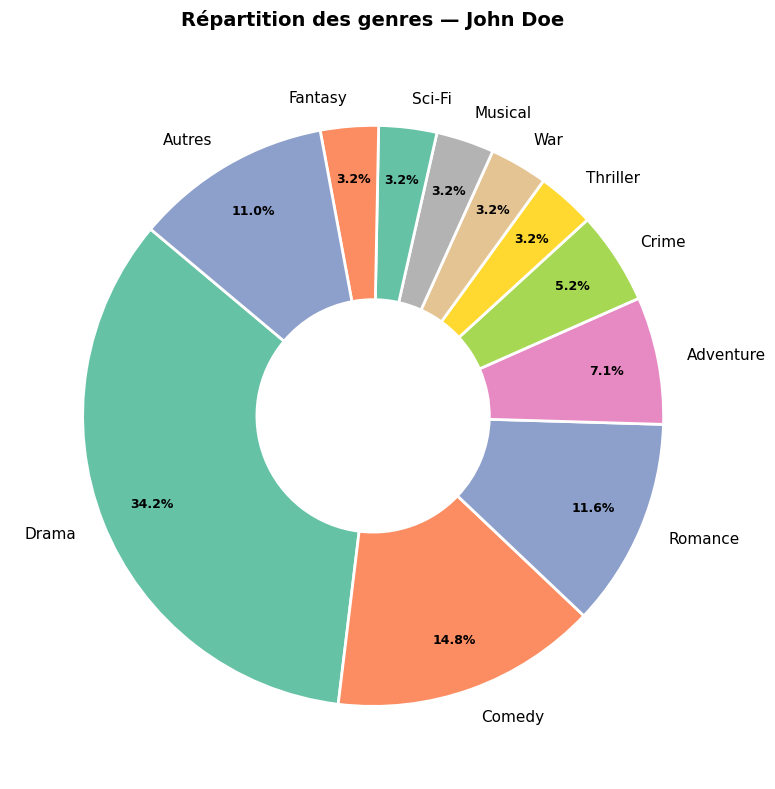

In [23]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# ── Rechargement des données (si la Phase 1 n'a pas été exécutée) ──
user    = pd.read_csv("./data/user_profiles_dataset.csv")
ratings = pd.read_csv("./data/ratings.csv")
movies  = pd.read_csv("./data/movies.csv")

def extraire_liste(valeur):
    if pd.isna(valeur): return []
    try: return ast.literal_eval(valeur)
    except: return []

user['interests'] = user['interests'].apply(extraire_liste)

historique_fusionne = pd.merge(ratings, movies, on='movieId', how='inner')
dictionnaire_historiques = {}
for uid, groupe in historique_fusionne.groupby('userId'):
    dictionnaire_historiques[uid] = [
        {"film": r['title'], "genre": r['genres'].split('|') if pd.notna(r['genres']) else [], "note": float(r['rating'])}
        for _, r in groupe.iterrows()
    ]

utilisateurs_structures = {}
for _, ligne in user.iterrows():
    uid = ligne['id']
    utilisateurs_structures[uid] = {
        "name": ligne['name'],
        "watch_history": dictionnaire_historiques.get(uid, [])
    }

# ── Visualisation ──────────────────────────────────────────────────
ID_UTILISATEUR = 1
profil = utilisateurs_structures.get(ID_UTILISATEUR)

if profil is None:
    print(f"Utilisateur {ID_UTILISATEUR} introuvable.")
else:
    tous_les_genres = []
    for film in profil["watch_history"]:
        tous_les_genres.extend(film["genre"])

    compteur_genres = Counter(tous_les_genres)
    total = sum(compteur_genres.values())
    labels, valeurs, autres = [], [], 0

    for genre, count in compteur_genres.most_common():
        if count / total >= 0.03:
            labels.append(genre)
            valeurs.append(count)
        else:
            autres += count

    if autres > 0:
        labels.append("Autres")
        valeurs.append(autres)

    couleurs = sns.color_palette("Set2", len(labels))
    fig, ax = plt.subplots(figsize=(8, 8))
    wedges, texts, autotexts = ax.pie(
        valeurs, labels=labels, autopct="%1.1f%%", colors=couleurs,
        startangle=140, pctdistance=0.82,
        wedgeprops=dict(width=0.6, edgecolor="white", linewidth=2)
    )
    for t in texts: t.set_fontsize(11)
    for at in autotexts: at.set_fontsize(9); at.set_fontweight("bold")
    ax.set_title(f"Répartition des genres — {profil['name']}", fontsize=14, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.show()

### Graphique Linéaire des Tendances Temporelles


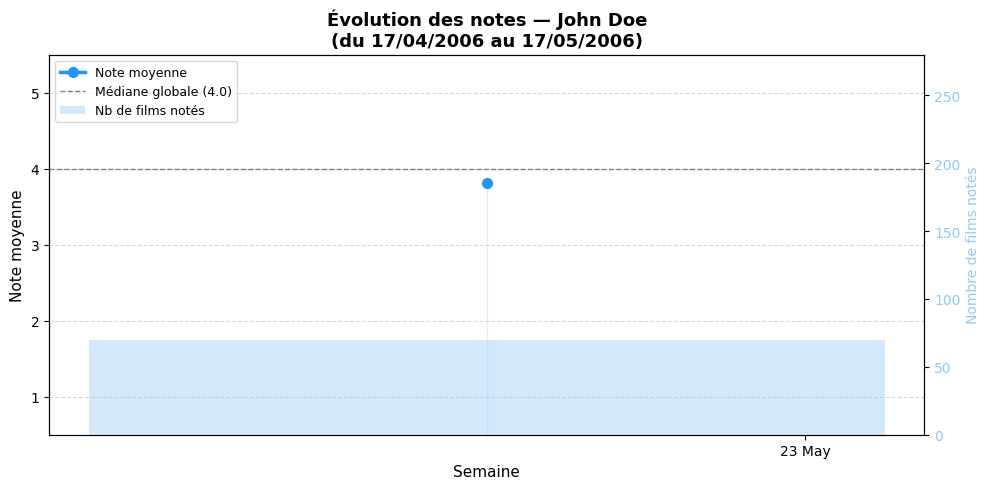

Semaines analysées : 1
Note médiane globale : 4.0


In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd

# ─── Paramètre : choisissez l'utilisateur à analyser ───────────────────────
ID_UTILISATEUR = 1
# ────────────────────────────────────────────────────────────────────────────

# Filtrage des notes de l'utilisateur
notes_utilisateur = ratings[ratings["userId"] == ID_UTILISATEUR].copy()

if notes_utilisateur.empty:
    print(f"Aucune note trouvée pour l'utilisateur {ID_UTILISATEUR}.")
else:
    # Conversion du timestamp Unix en dates lisibles
    notes_utilisateur["date"] = pd.to_datetime(
        notes_utilisateur["timestamp"], unit="s"
    )

    # Détermination du dernier mois d'activité
    date_max = notes_utilisateur["date"].max()
    date_debut = date_max - pd.DateOffset(months=1)
    dernier_mois = notes_utilisateur[notes_utilisateur["date"] >= date_debut].copy()

    if dernier_mois.empty:
        print("Pas assez de données sur le dernier mois. Affichage de toute l'activité.")
        dernier_mois = notes_utilisateur.copy()

    # Calcul de la moyenne des notes par semaine
    dernier_mois.set_index("date", inplace=True)
    moyennes_hebdo = (
        dernier_mois["rating"]
        .resample("W")          # agrégation par semaine
        .agg(["mean", "count"])
        .rename(columns={"mean": "note_moyenne", "count": "nb_notes"})
        .dropna()
    )

    # ── Tracé ──────────────────────────────────────────────────────────────
    fig, ax1 = plt.subplots(figsize=(10, 5))

    couleur_ligne = "#2196F3"
    couleur_barre = "#90CAF9"

    # Barres en arrière-plan : nombre de films notés par semaine
    ax2 = ax1.twinx()
    ax2.bar(
        moyennes_hebdo.index,
        moyennes_hebdo["nb_notes"],
        width=5,
        color=couleur_barre,
        alpha=0.4,
        label="Nb de films notés"
    )
    ax2.set_ylabel("Nombre de films notés", color=couleur_barre, fontsize=10)
    ax2.tick_params(axis="y", labelcolor=couleur_barre)
    ax2.set_ylim(0, moyennes_hebdo["nb_notes"].max() * 4)  # garde la ligne bien visible

    # Ligne principale : moyenne des notes par semaine
    ax1.plot(
        moyennes_hebdo.index,
        moyennes_hebdo["note_moyenne"],
        color=couleur_ligne,
        linewidth=2.5,
        marker="o",
        markersize=7,
        zorder=5,
        label="Note moyenne"
    )

    # Remplissage sous la courbe
    ax1.fill_between(
        moyennes_hebdo.index,
        moyennes_hebdo["note_moyenne"],
        alpha=0.15,
        color=couleur_ligne
    )

    # Ligne horizontale de référence (note médiane globale de l'utilisateur)
    mediane = notes_utilisateur["rating"].median()
    ax1.axhline(
        y=mediane,
        color="gray",
        linestyle="--",
        linewidth=1,
        label=f"Médiane globale ({mediane:.1f})"
    )

    # Formatage de l'axe des dates
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    plt.xticks(rotation=30)

    # Limites de l'axe Y (notes entre 0.5 et 5)
    ax1.set_ylim(0.5, 5.5)
    ax1.set_ylabel("Note moyenne", fontsize=11)
    ax1.set_xlabel("Semaine", fontsize=11)

    # Récupération du nom de l'utilisateur si disponible
    nom = utilisateurs_structures.get(ID_UTILISATEUR, {}).get("name", f"Utilisateur {ID_UTILISATEUR}")

    ax1.set_title(
        f"Évolution des notes — {nom}\n"
        f"(du {date_debut.strftime('%d/%m/%Y')} au {date_max.strftime('%d/%m/%Y')})",
        fontsize=13, fontweight="bold"
    )

    # Légendes combinées
    lignes1, etiquettes1 = ax1.get_legend_handles_labels()
    lignes2, etiquettes2 = ax2.get_legend_handles_labels()
    ax1.legend(lignes1 + lignes2, etiquettes1 + etiquettes2, loc="upper left", fontsize=9)

    ax1.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Résumé textuel de la tendance
    if len(moyennes_hebdo) >= 2:
        delta = moyennes_hebdo["note_moyenne"].iloc[-1] - moyennes_hebdo["note_moyenne"].iloc[0]
        tendance = "↑ en hausse" if delta > 0.1 else ("↓ en baisse" if delta < -0.1 else "→ stable")
        print(f"\nTendance pour {nom} : {tendance} ({delta:+.2f} sur la période)")
    print(f"Semaines analysées : {len(moyennes_hebdo)}")
    print(f"Note médiane globale : {mediane}")